# Import Libraries

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import Dataset

In [5]:
PATH = "../data/data.csv"
df = pd.read_csv(PATH)
df.columns = ['density', 'cutting_speed', 'feed_rate', 'depth', 'axial_force', 'cutting_force']

# Analysis

## General Check

### Shape & Dtypes

In [6]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nColumn names:\n", df.columns.tolist())
df

Shape: (283140, 6)

Dtypes:
 density            int64
cutting_speed      int64
feed_rate          int64
depth            float64
axial_force      float64
cutting_force    float64
dtype: object

Column names:
 ['density', 'cutting_speed', 'feed_rate', 'depth', 'axial_force', 'cutting_force']


,density,cutting_speed,feed_rate,depth,axial_force,cutting_force
0,10,100,10,0.000,1.089,2.603
1,10,100,10,0.017,1.164,2.678
2,10,100,10,0.033,1.239,2.753
3,10,100,10,0.050,1.313,2.828
4,10,100,10,0.067,1.388,2.903
...,...,...,...,...,...,...
283135,25,63,20,32.833,87.251,528.447
283136,25,63,20,32.867,87.251,528.447
283137,25,63,20,32.900,87.251,528.447
283138,25,63,20,32.933,87.251,528.447


### Summary Stats

In [7]:
df.describe(include="all")

,density,cutting_speed,feed_rate,depth,axial_force,cutting_force
count,283140.000000,283140.000000,283140.000000,283140.000000,283140.000000,283140.000000
mean,16.818182,42.333333,13.846154,16.488462,61.340750,165.362869
std,5.339709,31.084170,3.997047,9.526294,46.984345,208.960261
min,10.000000,10.000000,10.000000,0.000000,0.067000,-2.163000
25%,10.000000,16.000000,10.000000,8.233000,23.335000,31.844750
50%,15.000000,32.500000,15.000000,16.491500,44.753000,80.182000
75%,20.000000,63.000000,15.000000,24.733000,87.765250,221.766500
max,25.000000,100.000000,20.000000,32.983000,298.198000,1392.341000


### Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"missing": missing, "pct": missing_pct})
        .query("missing > 0")
        .sort_values("pct", ascending=False))


Empty DataFrame
Columns: [missing, pct]
Index: []


### Duplicates

In [9]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


### Unique Values per Column


In [10]:
print("\nUnique values per column:")
print(df.nunique().sort_values())


Unique values per column:
feed_rate             3
density               4
cutting_speed         6
depth              2640
axial_force      119488
cutting_force    182523
dtype: int64


### Numeric Distribution

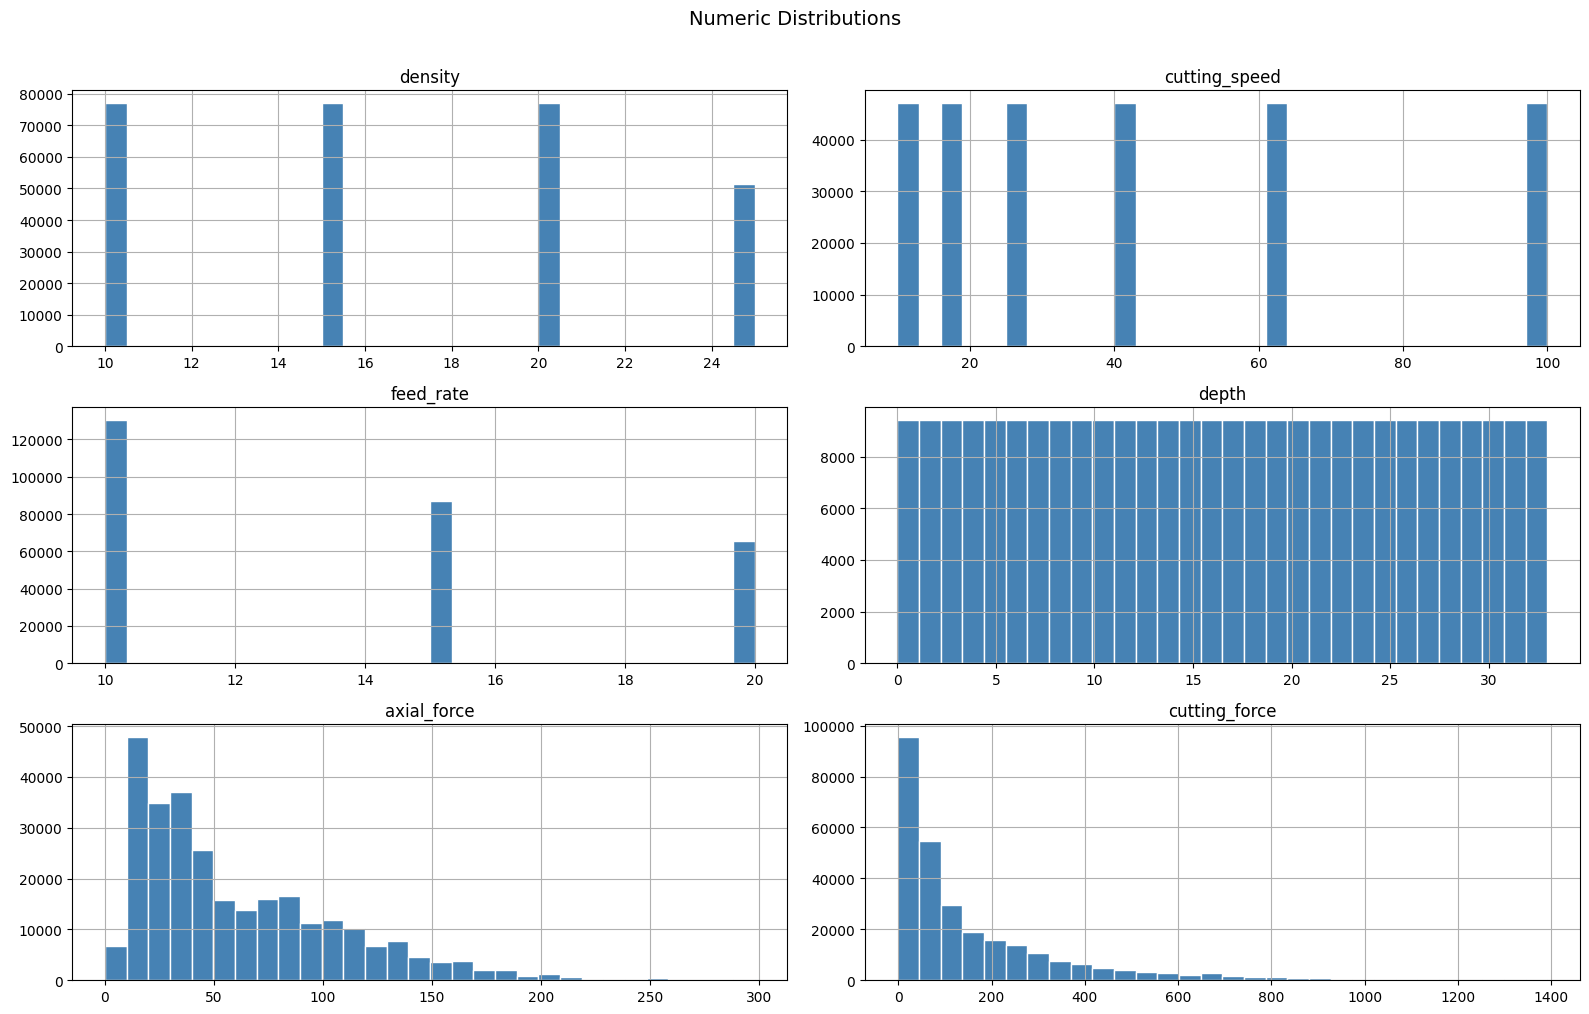

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=30, edgecolor="white", color="steelblue")
plt.suptitle("Numeric Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Boxplots

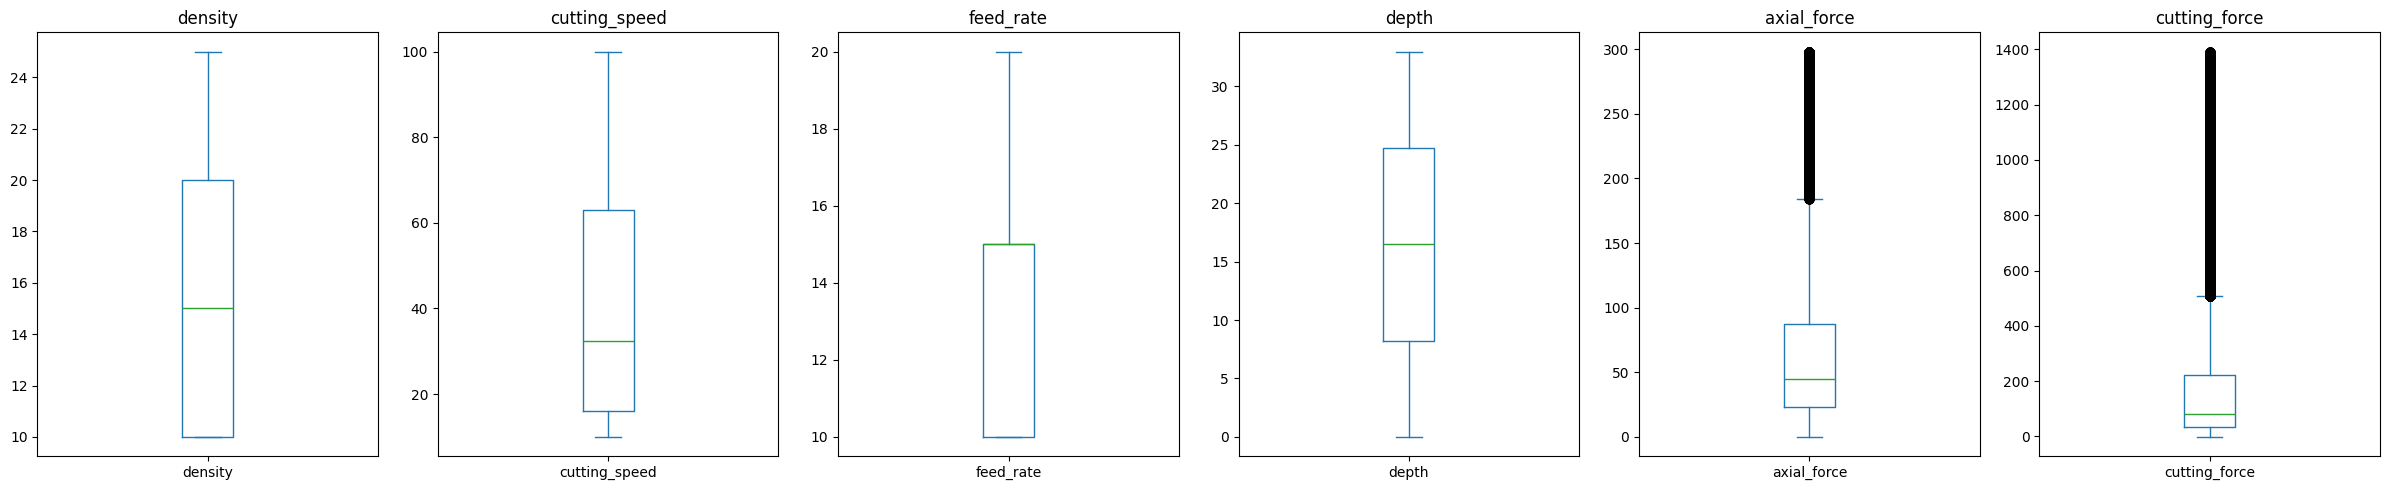

In [12]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    df[col].plot(kind="box", ax=ax, title=col)
plt.tight_layout()
plt.show()


### Correlation Heatmap

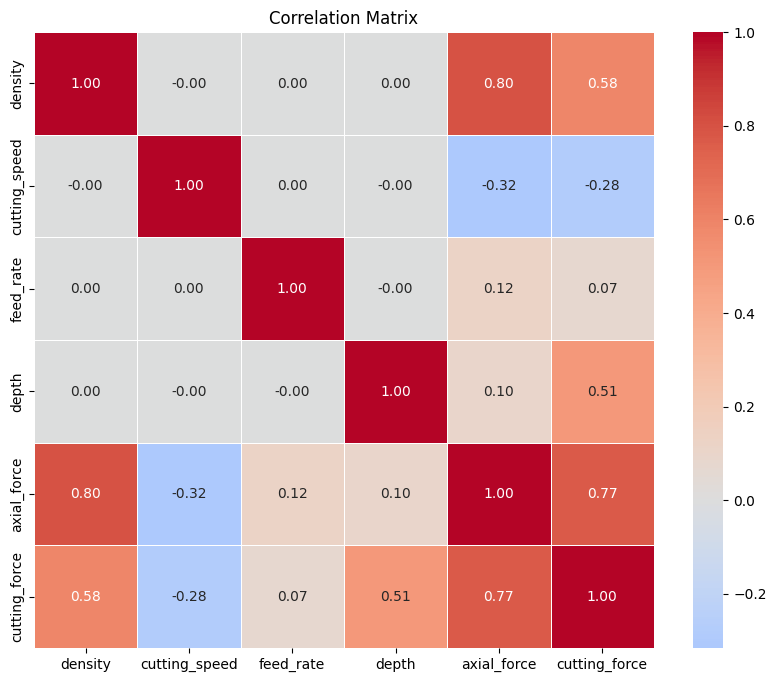

In [13]:
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Correlation Matrix")
    plt.show()

## Parameters Distribution for Each Insertiuon

### Parameters

In [14]:
params = ['density', 'cutting_speed', 'feed_rate']

df['experiment_id'] = df.groupby(params)['depth'].transform(
    lambda x: (x == 0).cumsum()
)

### Summary Table

In [15]:
summary = (df.groupby(params)['experiment_id']
             .max()
             .reset_index(name='experiment_count')
             .sort_values('experiment_count', ascending=False))

print(f"Total unique combinations: {len(summary)}")
print(f"Experiment count range: {summary['experiment_count'].min()} – {summary['experiment_count'].max()}")
print("\n── Experiments per combination ──")
display(summary)

Total unique combinations: 72
Experiment count range: 2 – 3

── Experiments per combination ──


,density,cutting_speed,feed_rate,experiment_count
0,10,10,10,3
1,10,10,15,3
2,10,10,20,3
3,10,16,10,3
4,10,16,15,3
...,...,...,...,...
67,25,63,15,2
68,25,63,20,2
69,25,100,10,2
70,25,100,15,2


### Total Experiment Conducted

In [16]:
total_experiments = summary['experiment_count'].sum()
print(f"Total experiments across all combinations: {total_experiments}")

Total experiments across all combinations: 198


count     198.000000
mean     1430.000000
std       412.625615
min       990.000000
25%       990.000000
50%      1320.000000
75%      1980.000000
max      1980.000000
dtype: float64


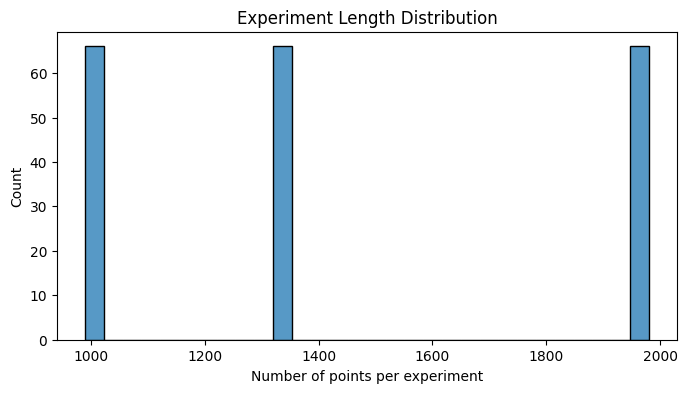

In [19]:
exp_lengths = (
    df.groupby(['density','cutting_speed','feed_rate','experiment_id'])
    .size()
)

print(exp_lengths.describe())

plt.figure(figsize=(8,4))
sns.histplot(exp_lengths, bins=30)
plt.xlabel("Number of points per experiment")
plt.ylabel("Count")
plt.title("Experiment Length Distribution")
plt.show()

In [20]:
print(summary.head(20))

    density  cutting_speed  feed_rate  experiment_count
0        10             10         10                 3
1        10             10         15                 3
2        10             10         20                 3
3        10             16         10                 3
4        10             16         15                 3
5        10             16         20                 3
6        10             25         10                 3
7        10             25         15                 3
8        10             25         20                 3
9        10             40         10                 3
10       10             40         15                 3
11       10             40         20                 3
12       10             63         10                 3
13       10             63         15                 3
14       10             63         20                 3
15       10            100         10                 3
16       10            100         15           

In [21]:
print(summary["experiment_count"].value_counts())


experiment_count
3    54
2    18
Name: count, dtype: int64


In [22]:
# pilih satu kombinasi parameter
sample = df[
    (df['density'] == 10) &
    (df['cutting_speed'] == 100) &
    (df['feed_rate'] == 10)
]

print(sample[['density','cutting_speed','feed_rate','experiment_id']].head())

   density  cutting_speed  feed_rate  experiment_id
0       10            100         10              1
1       10            100         10              1
2       10            100         10              1
3       10            100         10              1
4       10            100         10              1


In [23]:
exp = sample[sample['experiment_id'] == 1]

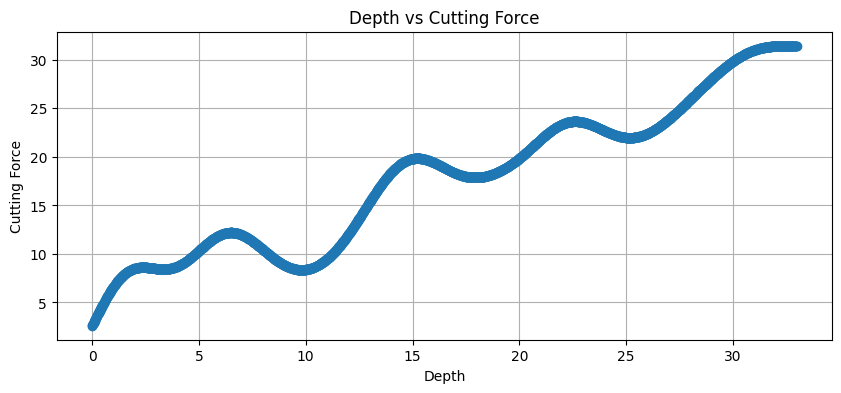

In [24]:
plt.figure(figsize=(10,4))

plt.plot(
    exp['depth'],
    exp['cutting_force'],
    marker='o'
)

plt.xlabel("Depth")
plt.ylabel("Cutting Force")
plt.title("Depth vs Cutting Force")

plt.grid()
plt.show()

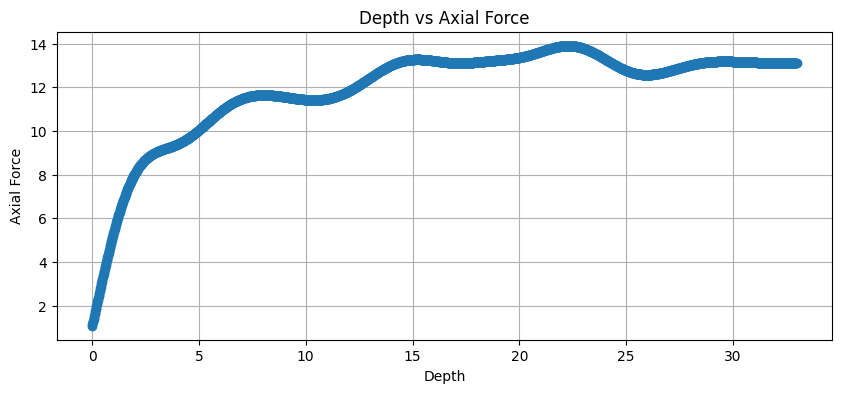

In [25]:
plt.figure(figsize=(10,4))

plt.plot(
    exp['depth'],
    exp['axial_force'],
    marker='o'
)

plt.xlabel("Depth")
plt.ylabel("Axial Force")
plt.title("Depth vs Axial Force")

plt.grid()
plt.show()

In [26]:
for col in ['depth','axial_force','cutting_force']:
    print(col)
    print(exp[col].diff().describe())
    print()

depth
count    1979.000000
mean        0.016666
std         0.000472
min         0.016000
25%         0.016000
50%         0.017000
75%         0.017000
max         0.017000
Name: depth, dtype: float64

axial_force
count    1979.000000
mean        0.006074
std         0.014827
min        -0.010000
25%        -0.001000
50%         0.002000
75%         0.007000
max         0.075000
Name: axial_force, dtype: float64

cutting_force
count    1979.000000
mean        0.014577
std         0.023493
min        -0.031000
25%        -0.003000
50%         0.015000
75%         0.032000
max         0.075000
Name: cutting_force, dtype: float64



### Full Grouped Detail

In [17]:
# print("\n── All rows grouped by combination ──")

# for combo, group in df.groupby(params):
#     density, cutting_speed, feed_rate = combo
#     n_exp = group['experiment_id'].max()
#     print(f"\n{'─'*60}")
#     print(f"density={density} | cutting_speed={cutting_speed} | feed_rate={feed_rate}  →  {n_exp} experiment(s)")
    
#     for exp_id, exp_group in group.groupby('experiment_id'):
#         print(f"  experiment {exp_id}:")
#         display(exp_group.drop(columns='experiment_id').reset_index(drop=True))